# Epsilon ($\epsilon$) Sweep for KL/ML Decoders — All 8 Error Profiles

**Goal.** The paper's main text adopts $\epsilon = 10^{-2}$ as the smoothing constant for the
KL / Max-Likelihood (ML) decoders, but this value was tuned only on **EZ17 / $\mathcal{A}_6$**
(see *rough_transaction_paper*, Table:Epsilon).

The supplementary results show that under high-error profiles (R21, B22, NP22, NPF22) and
on the larger uniform alphabet $\mathcal{A}_{11}$, KL/ML at $\epsilon = 10^{-2}$ **stagnates and
even loses to Minimum-Distance** at moderate-to-high coverage (Section *Baseline Decoder Behavior
Under High Errors*: NPF22/$\mathcal{A}_{11}$ at $M=25$ gives Min.D = 50.92% vs KL = 38.04%).

This notebook sweeps $\epsilon$ across all **8 error profiles**
(`EZ17, G15, O17, R21, B22, BOS22, NP22, NPF22`) and reports the value that maximises
**average symbol accuracy** over the evaluated coverage range. We focus on the
**$\mathcal{A}_{11}$ (`2mix_3mix_4mix`)** alphabet because that is where the largest KL/ML
deficits are observed in the supplementary tables — but the same code works for
`2mix_only` and `2mix_3mix` by changing one constant.

### Setup assumed
- `dataset_generator_uniform_composite.py` has already been run, producing
  files `./dataset/dna_<PROFILE>_<ALPHABET_MODE>_100000_25.pkl` (or `_50.pkl`).
- All code below mirrors the exact preprocessing / decoder definitions in
  `Train_evaluate_2mix_3mix_4mix-Erlich.py` so numbers are directly comparable to
  Table:ResultsA11 (main paper) and Table:Supp_ResultsA11 (supplementary).

### Reproducibility
Every (profile, M, $\epsilon$) experiment is deterministic:
1. The dataset is loaded once per profile from a fixed `.pkl`.
2. Test indices are drawn with a fixed `numpy.random.default_rng(MASTER_SEED)`,
   so the test split is identical across all $\epsilon$ values.
3. The `cluster[:M]` slice is order-preserving, so for the same M the same M reads are used.
4. `preprocess_cluster_to_matrix` is fully deterministic given a fixed read list.

This means: **`run(profile, M, eps_a)` and `run(profile, M, eps_b)` are evaluated on
byte-for-byte identical frequency matrices**, which isolates the effect of $\epsilon$.

## 1. Imports & global configuration

In [1]:
import os
import pickle
import random
import time
from collections import defaultdict

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Master seed — controls test-set sampling. Same seed -> same test split
# for every (profile, M, epsilon) configuration.
# ----------------------------------------------------------------------
MASTER_SEED = 42

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds(MASTER_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device       : {device}')
print(f'Master seed  : {MASTER_SEED}')

Device       : cuda
Master seed  : 42


## 2. Experiment configuration

- **Alphabet**: `2mix_3mix_4mix` (i.e. $\mathcal{A}_{11}$, 15 classes). Change `ALPHABET_MODE`
  to `'2mix_only'` ($\mathcal{A}_6$, 10 classes) or `'2mix_3mix'` ($\mathcal{A}_{10}$, 14 classes).
- **Coverage levels**: same set as the paper's Table:Supp_ResultsA11.
- **Epsilon grid**: the same 6 values as the paper's $\epsilon$ sensitivity table,
  plus a couple of larger values to catch the optimum under nanopore profiles.
- **Test size**: 10000 samples per (profile, M, ε). The 10000 indices are drawn once,
  with `MASTER_SEED`, and reused for every sweep.

In [2]:
# ----------------------------------------------------------------------
# Dataset / alphabet selection
# ----------------------------------------------------------------------
DATASET_DIR  = './dataset'
NUM_SAMPLES  = 100000   # must match the .pkl produced by dataset_generator_uniform_composite.py
MAX_COVERAGE = 50       # the M in the .pkl filename: dna_<PROF>_<MODE>_<N>_<M>.pkl
ALPHABET_MODE = '2mix_3mix_4mix'   # A_11 (15 classes). Other options: '2mix_only', '2mix_3mix'

VOCAB_SIZES = {
    '2mix_only':        10,
    '2mix_3mix':        14,
    '2mix_3mix_4mix':   15,
}
VOCAB_SIZE = VOCAB_SIZES[ALPHABET_MODE]

# Per-profile sequence lengths (must match the dataset generator)
PROFILE_SPECS = {
    'EZ17':  {'seq_length': 136, 'platform': 'Illumina miSeq + Twist',         'family': 'Illumina'},
    'G15':   {'seq_length': 104, 'platform': 'Illumina miSeq + CustomArray',   'family': 'Illumina'},
    'O17':   {'seq_length':  77, 'platform': 'Illumina NextSeq + Twist',       'family': 'Illumina'},
    'R21':   {'seq_length': 136, 'platform': 'Nanopore MinION + Twist',        'family': 'Nanopore'},
    'B22':   {'seq_length': 136, 'platform': 'Nanopore MinION-short + Twist',  'family': 'Nanopore'},
    'BOS22': {'seq_length': 136, 'platform': 'Illumina miSeq 2022 + Twist',    'family': 'Illumina'},
    'NP22':  {'seq_length': 136, 'platform': 'Nanopore Pilot Nov-2022',        'family': 'Nanopore'},
    'NPF22': {'seq_length': 136, 'platform': 'Nanopore Full Nov-2022',         'family': 'Nanopore'},
}
ALL_PROFILES = list(PROFILE_SPECS.keys())

# ----------------------------------------------------------------------
# Coverage levels & epsilon grid
# ----------------------------------------------------------------------
# Same M-grid as paper Table:Supp_ResultsA11
COVERAGE_LEVELS = [1, 2, 3, 5, 8, 10, 15, 20, 25]

# Same 6 values as paper Table:Epsilon, plus larger ones to find the optimum
# under nanopore profiles where the supplementary observed KL/ML stagnation
EPSILON_GRID = [1e-10, 1e-5, 1e-3, 1e-2, 0.05, 0.1, 0.2, 0.3, 0.5]

# Test-set size (held fixed across all epsilon values via MASTER_SEED)
NUM_TEST = 10000

# Results directory
RESULTS_DIR = f'./results_epsilon_sweep_{ALPHABET_MODE}'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Alphabet mode    : {ALPHABET_MODE}  (vocab_size = {VOCAB_SIZE})')
print(f'Coverage levels  : {COVERAGE_LEVELS}')
print(f'Epsilon grid     : {EPSILON_GRID}')
print(f'Test samples     : {NUM_TEST:,}')
print(f'Results dir      : {RESULTS_DIR}')
print(f'Profiles         : {ALL_PROFILES}')

Alphabet mode    : 2mix_3mix_4mix  (vocab_size = 15)
Coverage levels  : [1, 2, 3, 5, 8, 10, 15, 20, 25]
Epsilon grid     : [1e-10, 1e-05, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
Test samples     : 10,000
Results dir      : ./results_epsilon_sweep_2mix_3mix_4mix
Profiles         : ['EZ17', 'G15', 'O17', 'R21', 'B22', 'BOS22', 'NP22', 'NPF22']


## 3. Symbol mappings & ideal frequency vectors

Exact copy of `build_symbol_to_idx` / `build_ideal_vectors` from
`Train_evaluate_2mix_3mix_4mix-Erlich.py` so the ideal-vector table is identical
to the one used in the paper.

In [3]:
def build_symbol_to_idx(mode):
    symbol_to_idx = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    symbol_to_idx.update({'M1': 4, 'M2': 5, 'M3': 6, 'M4': 7, 'M5': 8, 'M6': 9})
    if mode in ('2mix_3mix', '2mix_3mix_4mix'):
        symbol_to_idx.update({'T1': 10, 'T2': 11, 'T3': 12, 'T4': 13})
    if mode == '2mix_3mix_4mix':
        symbol_to_idx.update({'Q1': 14})
    return symbol_to_idx


def build_ideal_vectors(mode):
    ideal_vectors = [
        [1.0, 0.0, 0.0, 0.0],  # A
        [0.0, 1.0, 0.0, 0.0],  # C
        [0.0, 0.0, 1.0, 0.0],  # G
        [0.0, 0.0, 0.0, 1.0],  # T
        # Two-mix (uniform 0.5/0.5)
        [0.5, 0.0, 0.0, 0.5],  # M1 A|T
        [0.0, 0.5, 0.5, 0.0],  # M2 C|G
        [0.0, 0.5, 0.0, 0.5],  # M3 C|T
        [0.0, 0.0, 0.5, 0.5],  # M4 G|T
        [0.5, 0.5, 0.0, 0.0],  # M5 A|C
        [0.5, 0.0, 0.5, 0.0],  # M6 A|G
    ]
    if mode in ('2mix_3mix', '2mix_3mix_4mix'):
        third = 1.0 / 3.0
        ideal_vectors.extend([
            [third, third, third, 0.0],   # T1
            [third, third, 0.0, third],   # T2
            [third, 0.0, third, third],   # T3
            [0.0, third, third, third],   # T4
        ])
    if mode == '2mix_3mix_4mix':
        ideal_vectors.append([0.25, 0.25, 0.25, 0.25])  # Q1
    return torch.tensor(ideal_vectors, dtype=torch.float32)


SYMBOL_TO_IDX = build_symbol_to_idx(ALPHABET_MODE)
IDX_TO_SYMBOL = {v: k for k, v in SYMBOL_TO_IDX.items()}
IDEAL_VECTORS = build_ideal_vectors(ALPHABET_MODE).to(device)

assert IDEAL_VECTORS.shape == (VOCAB_SIZE, 4)
print(f'Ideal vectors shape: {tuple(IDEAL_VECTORS.shape)}')
print(f'Symbols           : {list(SYMBOL_TO_IDX.keys())}')

Ideal vectors shape: (15, 4)
Symbols           : ['A', 'C', 'G', 'T', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'T1', 'T2', 'T3', 'T4', 'Q1']


## 4. Preprocessing & baseline decoders

Exact copy from the project's train/evaluate scripts so the frequency-matrix
construction is identical.

- `preprocess_cluster_to_matrix(reads, target_length)` — Eq. (FrequencyMatrix)
  with linear-interpolation alignment (Eq. Alignment).
- `min_distance_decoder` — $\ell_2$ argmin.
- `kl_ml_decoder` — KL divergence == ML decoder, parameterised by `epsilon`.

> **Note.** KL and ML are mathematically equivalent (Prop:KLMLEquiv), so we only
> implement one routine. The notebook's tables call it "KL/ML".

In [4]:
# -------- Preprocessing (exact copy of preprocess_cluster_to_matrix) ----------

def preprocess_cluster_to_matrix(cluster_reads, target_length):
    """
    Convert variable-length noisy reads into a (4, target_length) normalized frequency
    matrix via the paper's linear-interpolation alignment.
    """
    profile_matrix = np.zeros((4, target_length), dtype=np.float32)
    base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    num_reads = len(cluster_reads)

    for read in cluster_reads:
        read_len = len(read)
        if read_len == 0:
            continue
        for t_idx in range(target_length):
            read_idx = int((t_idx + 0.5) * (read_len / target_length))
            if read_idx >= read_len:
                read_idx = read_len - 1
            base = read[read_idx]
            if base in base_map:
                profile_matrix[base_map[base], t_idx] += 1.0

    if num_reads > 0:
        profile_matrix /= num_reads
    return profile_matrix


# -------- Decoders ------------------------------------------------------------

def min_distance_decoder(obs, ideal_vectors):
    """
    Minimum Euclidean Distance decoder.
    obs           : (B, L, 4)  observed frequency vectors
    ideal_vectors : (C, 4)     ideal frequency vectors
    Returns       : (B, L)     predicted class indices
    """
    dists = torch.sum(
        (obs.unsqueeze(2) - ideal_vectors.unsqueeze(0).unsqueeze(0)) ** 2,
        dim=3,
    )
    return torch.argmin(dists, dim=2)


def kl_ml_decoder(obs, ideal_vectors, epsilon):
    """
    KL-divergence == Maximum-Likelihood decoder (Prop:KLMLEquiv).
    Identical numerical recipe to kl_divergence_decoder / maximum_likelihood_decoder
    in the project scripts: clamp ideal vectors to `epsilon`, renormalise, then
    minimise cross-entropy.
    """
    ideal_safe = ideal_vectors.clone()
    ideal_safe = torch.clamp(ideal_safe, min=epsilon)
    ideal_safe = ideal_safe / ideal_safe.sum(dim=-1, keepdim=True)

    log_ideal    = torch.log(ideal_safe).unsqueeze(0).unsqueeze(0)   # (1,1,C,4)
    obs_expanded = obs.unsqueeze(2)                                  # (B,L,1,4)
    cross_entropy = -(obs_expanded * log_ideal).sum(dim=-1)          # (B,L,C)
    return torch.argmin(cross_entropy, dim=-1)


print('Preprocessing & decoder functions ready.')

Preprocessing & decoder functions ready.


## 5. Deterministic test-set sampler

For every profile we deterministically draw the same `NUM_TEST` sample indices
using `numpy.random.default_rng(MASTER_SEED)`. The test indices are a function only
of `(num_total, NUM_TEST, MASTER_SEED)` — not of $M$ or $\epsilon$ — so the same
samples are evaluated for every coverage and every epsilon.

In [5]:
def sample_test_indices(num_total, num_test, seed):
    """
    Draw `num_test` indices in [0, num_total) deterministically from `seed`.
    Same num_total + seed -> always same indices.
    """
    rng = np.random.default_rng(seed)
    return rng.choice(num_total, size=num_test, replace=False)


# Smoke test
_demo_idx_1 = sample_test_indices(100000, 10, MASTER_SEED)
_demo_idx_2 = sample_test_indices(100000, 10, MASTER_SEED)
assert np.array_equal(_demo_idx_1, _demo_idx_2), 'Sampler is not deterministic!'
print('Deterministic sampler OK. First 10 test indices @ N=100k:', _demo_idx_1.tolist())

Deterministic sampler OK. First 10 test indices @ N=100k: [8594, 77389, 8924, 65452, 43885, 43299, 69735, 9417, 20146, 85856]


## 6. Locate the pickle for each profile

Filename convention from `dataset_generator_uniform_composite.py`:

```
{DATASET_DIR}/dna_{PROFILE}_{ALPHABET_MODE}_{NUM_SAMPLES}_{MAX_COVERAGE}.pkl
```
e.g. `./dataset/dna_EZ17_2mix_3mix_4mix_100000_25.pkl`.

In [6]:
def dataset_path_for(profile_name):
    fname = f'dna_{profile_name}_{ALPHABET_MODE}_{NUM_SAMPLES}_{MAX_COVERAGE}.pkl'
    return os.path.join(DATASET_DIR, fname)


# Sanity check: which datasets are available
print('Dataset availability check:')
print('-' * 72)
available = []
for p in ALL_PROFILES:
    path = dataset_path_for(p)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f'  [OK]   {p:<6}  ({size_mb:6.1f} MB)  {path}')
        available.append(p)
    else:
        print(f'  [MISS] {p:<6}                  {path}')

if not available:
    raise FileNotFoundError(
        'No datasets found. Run dataset_generator_uniform_composite.py first with '
        f"ERROR_MODEL = 'ALL' and ALPHABET_MODE = '{ALPHABET_MODE}'."
    )

print(f'\nAvailable profiles: {available}')

Dataset availability check:
------------------------------------------------------------------------
  [OK]   EZ17    ( 690.3 MB)  ./dataset/dna_EZ17_2mix_3mix_4mix_100000_50.pkl
  [OK]   G15     ( 529.5 MB)  ./dataset/dna_G15_2mix_3mix_4mix_100000_50.pkl
  [OK]   O17     ( 398.0 MB)  ./dataset/dna_O17_2mix_3mix_4mix_100000_50.pkl
  [OK]   R21     ( 688.3 MB)  ./dataset/dna_R21_2mix_3mix_4mix_100000_50.pkl
  [OK]   B22     ( 689.6 MB)  ./dataset/dna_B22_2mix_3mix_4mix_100000_50.pkl
  [OK]   BOS22   ( 690.9 MB)  ./dataset/dna_BOS22_2mix_3mix_4mix_100000_50.pkl
  [OK]   NP22    ( 688.5 MB)  ./dataset/dna_NP22_2mix_3mix_4mix_100000_50.pkl
  [OK]   NPF22   ( 688.4 MB)  ./dataset/dna_NPF22_2mix_3mix_4mix_100000_50.pkl

Available profiles: ['EZ17', 'G15', 'O17', 'R21', 'B22', 'BOS22', 'NP22', 'NPF22']


## 7. Build the per-(profile, M) frequency-matrix cache

This is the **key reproducibility trick**: for every profile we precompute the
$(4 \times n)$ frequency matrix for each test sample at *every* coverage level
**before** running the epsilon sweep. The matrices are stored in a dict keyed by
$M$, then every epsilon evaluation simply uses the same cached matrices.

Because:
- the test indices come from `MASTER_SEED`,
- `cluster[:M]` is order-preserving,
- `preprocess_cluster_to_matrix` is fully deterministic,

running the cell twice in a fresh kernel produces byte-for-byte identical caches.

> Memory note. For $\mathcal{A}_{11}$ at $n=136$, 10k samples × 4 × 136 × float32
> ≈ 22 MB per coverage level, ≈ 200 MB across all coverage levels. Comfortably fits
> in RAM. If memory becomes a concern, drop a few entries from `COVERAGE_LEVELS`.

In [7]:
def build_freq_matrix_cache(profile_name, coverage_levels, num_test, master_seed):
    """
    Load the profile's pickle once, draw the test indices deterministically,
    and precompute the (4, n) frequency matrix for each test sample at every M.

    Returns
    -------
    cache : dict
        {
          'profile'   : str,
          'seq_length': int,
          'labels'    : np.ndarray int64 (num_test, n) -- ground-truth class indices,
          'matrices'  : dict { M : torch.Tensor (num_test, 4, n) on CPU },
          'test_idx'  : np.ndarray int64 (num_test,)  -- which samples were drawn,
        }
    """
    path = dataset_path_for(profile_name)
    with open(path, 'rb') as f:
        ds = pickle.load(f)

    samples = ds['data']
    seq_length = ds['metadata']['seq_length']
    sym_to_idx_pkl = ds['metadata']['symbol_to_idx']

    # Cross-check the alphabet
    assert sym_to_idx_pkl == SYMBOL_TO_IDX, (
        f"Pickle {path} has different symbol_to_idx than the current ALPHABET_MODE."
    )

    # Deterministic test indices
    test_idx = sample_test_indices(len(samples), num_test, master_seed)

    # Labels (n,) ints
    labels = np.empty((num_test, seq_length), dtype=np.int64)
    for i, src_i in enumerate(test_idx):
        lbl = samples[src_i]['label']
        labels[i] = np.fromiter((SYMBOL_TO_IDX[s] for s in lbl), dtype=np.int64, count=seq_length)

    # Frequency matrices for every M
    matrices = {}
    for M in coverage_levels:
        mat = np.empty((num_test, 4, seq_length), dtype=np.float32)
        for i, src_i in enumerate(test_idx):
            cluster = samples[src_i]['cluster']
            m_use = min(M, len(cluster))
            reads = cluster[:m_use]  # order-preserving slice -- deterministic
            mat[i] = preprocess_cluster_to_matrix(reads, seq_length)
        matrices[M] = torch.from_numpy(mat)  # keep on CPU until used

    cache = {
        'profile':    profile_name,
        'seq_length': seq_length,
        'labels':     labels,
        'matrices':   matrices,
        'test_idx':   test_idx,
    }
    return cache


print('Cache builder ready.')

Cache builder ready.


## 8. Run the $\epsilon$-sweep on the cached matrices

For each $(M, \epsilon)$ we batch the (10k, 4, n) tensor onto the GPU/CPU
and call the decoder once. We also evaluate `min_distance_decoder` once per M
(it doesn't depend on $\epsilon$) for reference.

**Accuracy** is symbol-level, exactly as defined in the project's `evaluate_baselines`:
`accuracy = (predicted == label).mean() * 100`.

In [8]:
def sweep_profile(cache, eps_grid, coverage_levels, batch_size=2000):
    """
    For one profile cache, return:
      - md_acc : dict { M : Min.D accuracy% }
      - kl_acc : dict { (M, eps) : KL/ML accuracy% }
    """
    md_acc = {}
    kl_acc = {}

    labels_np = cache['labels']                  # (N, n) int64
    labels_t  = torch.from_numpy(labels_np).to(device)

    for M in coverage_levels:
        mat_cpu = cache['matrices'][M]           # (N, 4, n) float32
        N, _, n = mat_cpu.shape

        # ----- Minimum-Distance accuracy (independent of epsilon) -----
        correct_md = 0
        total      = N * n
        for start in range(0, N, batch_size):
            end   = min(start + batch_size, N)
            mat_b = mat_cpu[start:end].to(device)
            obs   = mat_b.permute(0, 2, 1)        # (B, n, 4)
            preds = min_distance_decoder(obs, IDEAL_VECTORS)
            correct_md += (preds == labels_t[start:end]).sum().item()
        md_acc[M] = 100.0 * correct_md / total

        # ----- KL/ML accuracy at every epsilon -----
        for eps in eps_grid:
            correct_kl = 0
            for start in range(0, N, batch_size):
                end   = min(start + batch_size, N)
                mat_b = mat_cpu[start:end].to(device)
                obs   = mat_b.permute(0, 2, 1)
                preds = kl_ml_decoder(obs, IDEAL_VECTORS, epsilon=eps)
                correct_kl += (preds == labels_t[start:end]).sum().item()
            kl_acc[(M, eps)] = 100.0 * correct_kl / total

    return md_acc, kl_acc


print('Sweep function ready.')

Sweep function ready.


## 9. Run the sweep on all 8 profiles

This is the long-running cell. For each profile we:

1. Build the matrix cache (≈ 1 min per profile on CPU, faster on GPU).
2. Sweep all $(M, \epsilon)$ combinations on the cached matrices.
3. Free the cache before moving on.

Total experiments evaluated:
$8 \text{ profiles} \times 9 \text{ M} \times 9 \text{ }\epsilon = 648$ KL/ML configs,
plus $8 \times 9 = 72$ Min.D configs.

Results are streamed into `RESULTS_DIR` after every profile, so a Ctrl-C still
leaves the partial results on disk.

In [9]:
profile_md_acc = {}    # {profile : {M : acc}}
profile_kl_acc = {}    # {profile : {(M, eps) : acc}}

profiles_to_run = [p for p in ALL_PROFILES if os.path.exists(dataset_path_for(p))]
print(f'Running sweep on {len(profiles_to_run)} profiles: {profiles_to_run}\n')

t_global = time.time()
for k, profile in enumerate(profiles_to_run, start=1):
    print('=' * 72)
    print(f'[{k}/{len(profiles_to_run)}] {profile}  '
          f'({PROFILE_SPECS[profile]["family"]}, n={PROFILE_SPECS[profile]["seq_length"]})')
    print('=' * 72)

    t0 = time.time()
    cache = build_freq_matrix_cache(profile, COVERAGE_LEVELS, NUM_TEST, MASTER_SEED)
    print(f'  cache built in {time.time() - t0:.1f}s '
          f'(test_idx[:5] = {cache["test_idx"][:5].tolist()})')

    t0 = time.time()
    md_acc, kl_acc = sweep_profile(cache, EPSILON_GRID, COVERAGE_LEVELS)
    print(f'  sweep done in  {time.time() - t0:.1f}s')

    profile_md_acc[profile] = md_acc
    profile_kl_acc[profile] = kl_acc

    # Persist incremental results
    out_path = os.path.join(RESULTS_DIR, f'sweep_{profile}.pkl')
    with open(out_path, 'wb') as f:
        pickle.dump({
            'profile': profile,
            'alphabet_mode': ALPHABET_MODE,
            'coverage_levels': COVERAGE_LEVELS,
            'epsilon_grid': EPSILON_GRID,
            'md_acc': md_acc,
            'kl_acc': kl_acc,
            'master_seed': MASTER_SEED,
            'num_test': NUM_TEST,
            'test_idx': cache['test_idx'],
        }, f)
    print(f'  saved -> {out_path}')

    # Free the cache (large) before the next profile
    del cache

print(f'\nTotal sweep time: {time.time() - t_global:.1f}s')

Running sweep on 8 profiles: ['EZ17', 'G15', 'O17', 'R21', 'B22', 'BOS22', 'NP22', 'NPF22']

[1/8] EZ17  (Illumina, n=136)
  cache built in 260.8s (test_idx[:5] = [94144, 50896, 31787, 89710, 42405])
  sweep done in  0.8s
  saved -> ./results_epsilon_sweep_2mix_3mix_4mix/sweep_EZ17.pkl
[2/8] G15  (Illumina, n=104)
  cache built in 190.5s (test_idx[:5] = [94144, 50896, 31787, 89710, 42405])
  sweep done in  1.0s
  saved -> ./results_epsilon_sweep_2mix_3mix_4mix/sweep_G15.pkl
[3/8] O17  (Illumina, n=77)
  cache built in 141.8s (test_idx[:5] = [94144, 50896, 31787, 89710, 42405])
  sweep done in  0.5s
  saved -> ./results_epsilon_sweep_2mix_3mix_4mix/sweep_O17.pkl
[4/8] R21  (Nanopore, n=136)
  cache built in 247.5s (test_idx[:5] = [94144, 50896, 31787, 89710, 42405])
  sweep done in  0.7s
  saved -> ./results_epsilon_sweep_2mix_3mix_4mix/sweep_R21.pkl
[5/8] B22  (Nanopore, n=136)
  cache built in 248.7s (test_idx[:5] = [94144, 50896, 31787, 89710, 42405])
  sweep done in  0.8s
  saved ->

## 10. Per-profile accuracy tables

For every profile we print an `M × ε` accuracy table for KL/ML, plus the
Min.D column for reference. The starred value in each row is the best
$\epsilon$ for that particular M.

In [10]:
def fmt_pct(x):
    return f'{x:6.2f}'


def print_profile_table(profile, md_acc, kl_acc):
    n = PROFILE_SPECS[profile]['seq_length']
    fam = PROFILE_SPECS[profile]['family']
    print('=' * 100)
    print(f'  Profile {profile}  ({fam}, n={n}, alphabet={ALPHABET_MODE})')
    print('=' * 100)

    header = '   M  | ' + 'Min.D  | ' + ' '.join(f'eps={e:<8.0e}' for e in EPSILON_GRID)
    print(header)
    print('-' * len(header))

    eps_avg_acc = {e: [] for e in EPSILON_GRID}
    md_avg = []

    for M in COVERAGE_LEVELS:
        row_vals = [kl_acc[(M, e)] for e in EPSILON_GRID]
        best_idx = int(np.argmax(row_vals))
        row_strs = []
        for j, v in enumerate(row_vals):
            cell = fmt_pct(v)
            row_strs.append(f'*{cell}*' if j == best_idx else f' {cell} ')

        print(f'  {M:>3} | {fmt_pct(md_acc[M])} | ' + ' '.join(row_strs))

        md_avg.append(md_acc[M])
        for e, v in zip(EPSILON_GRID, row_vals):
            eps_avg_acc[e].append(v)

    # Average row
    avg_md  = float(np.mean(md_avg))
    avg_eps = {e: float(np.mean(eps_avg_acc[e])) for e in EPSILON_GRID}
    best_eps_overall = max(avg_eps, key=lambda e: avg_eps[e])

    avg_row = ['*' + fmt_pct(v) + '*' if e == best_eps_overall else ' ' + fmt_pct(v) + ' '
               for e, v in avg_eps.items()]
    print('-' * len(header))
    print(f'  Avg | {fmt_pct(avg_md)} | ' + ' '.join(avg_row))
    print(f'\n  >>>>  Best epsilon by AVG accuracy: {best_eps_overall:.0e}  '
          f'(avg KL/ML acc = {avg_eps[best_eps_overall]:.2f}%, '
          f'Min.D avg = {avg_md:.2f}%) <<<<')
    print()
    return best_eps_overall, avg_eps, avg_md


best_eps_per_profile = {}
avg_acc_per_profile  = {}
md_avg_per_profile   = {}
for p in profiles_to_run:
    best, avg_eps, md_avg = print_profile_table(p, profile_md_acc[p], profile_kl_acc[p])
    best_eps_per_profile[p] = best
    avg_acc_per_profile[p]  = avg_eps
    md_avg_per_profile[p]   = md_avg

  Profile EZ17  (Illumina, n=136, alphabet=2mix_3mix_4mix)
   M  | Min.D  | eps=1e-10    eps=1e-05    eps=1e-03    eps=1e-02    eps=5e-02    eps=1e-01    eps=2e-01    eps=3e-01    eps=5e-01   
-------------------------------------------------------------------------------------------------------------------------------------
    1 |  25.30 | * 25.30*   25.30    25.30    25.30    25.30    25.30    25.30    25.30    25.30 
    2 |  42.63 | * 42.63*   42.63    42.63    42.63    42.63    42.63    42.63    42.63    25.33 
    3 |  55.51 | * 55.51*   55.51    55.51    55.51    55.51    55.51    32.07    27.06    26.48 
    5 |  63.63 | * 69.09*   69.09    69.09    69.09    63.63    57.97    49.72    28.70    26.66 
    8 |  67.12 |   73.12    73.12    73.12  * 77.90*   72.73    66.83    54.53    39.94    26.69 
   10 |  79.66 |   71.85    71.85    78.60  * 82.38*   79.96    77.46    56.54    38.76    26.70 
   15 |  87.95 |   65.94    65.94    75.83  * 90.65*   87.94    84.78    58.59    44.

## 11. Recommended $\epsilon$ per profile (summary)

The summary below reports, for each profile:

- **Best $\epsilon$** under two selection criteria:
  - *AvgAcc*: maximise the **average** KL/ML accuracy across all $M$ in `COVERAGE_LEVELS`
    (this matches the paper's choice criterion in Table:Epsilon).
  - *MaxMin*: maximise the **minimum** KL/ML accuracy across all $M$
    (a worst-case-coverage criterion; useful if you care about robust performance at every coverage).
- **AvgKL/ML acc** at that $\epsilon$.
- **AvgMin.D** for comparison (ε-independent).
- **$\Delta_{\text{vs Min.D}}$**: how much KL/ML at the best $\epsilon$ beats (positive)
  or trails (negative) Minimum Distance on average.

In [11]:
rows = []
for p in profiles_to_run:
    avg_eps_dict = avg_acc_per_profile[p]
    # AvgAcc criterion
    best_avg = max(avg_eps_dict, key=lambda e: avg_eps_dict[e])
    best_avg_val = avg_eps_dict[best_avg]
    # MaxMin criterion
    minacc = {e: min(profile_kl_acc[p][(M, e)] for M in COVERAGE_LEVELS) for e in EPSILON_GRID}
    best_maxmin = max(minacc, key=lambda e: minacc[e])
    best_maxmin_val = minacc[best_maxmin]
    md_avg = md_avg_per_profile[p]

    rows.append({
        'Profile':           p,
        'Family':            PROFILE_SPECS[p]['family'],
        'n':                 PROFILE_SPECS[p]['seq_length'],
        'Best eps (AvgAcc)': best_avg,
        'AvgKL @best':       best_avg_val,
        'AvgMin.D':          md_avg,
        'Delta vs Min.D':    best_avg_val - md_avg,
        'Best eps (MaxMin)': best_maxmin,
        'MinKL @best':       best_maxmin_val,
    })

summary_df = pd.DataFrame(rows)
print('=' * 100)
print('  SUMMARY  recommended epsilon per profile')
print(f'  Alphabet: {ALPHABET_MODE}   Coverage levels: {COVERAGE_LEVELS}')
print('=' * 100)
with pd.option_context('display.float_format', '{:.4g}'.format, 'display.width', 120):
    print(summary_df.to_string(index=False))

summary_csv = os.path.join(RESULTS_DIR, f'summary_best_epsilon_{ALPHABET_MODE}.csv')
summary_df.to_csv(summary_csv, index=False)
print(f'\nSaved summary -> {summary_csv}')

  SUMMARY  recommended epsilon per profile
  Alphabet: 2mix_3mix_4mix   Coverage levels: [1, 2, 3, 5, 8, 10, 15, 20, 25]
Profile   Family   n  Best eps (AvgAcc)  AvgKL @best  AvgMin.D  Delta vs Min.D  Best eps (MaxMin)  MinKL @best
   EZ17 Illumina 136               0.01        70.06     67.33           2.734              1e-10         25.3
    G15 Illumina 104               0.05        60.59     60.33          0.2595              1e-10        23.45
    O17 Illumina  77               0.01        74.13     68.97           5.161              1e-10        25.97
    R21 Nanopore 136                0.1        30.45     29.08           1.368              0.001        16.07
    B22 Nanopore 136                0.1        37.28        36           1.275              0.001        17.93
  BOS22 Illumina 136              0.001        77.92      69.9            8.02              1e-10        26.53
   NP22 Nanopore 136                0.1         34.3     32.96            1.34              0.001     

## 12. Plots: KL/ML accuracy vs $\epsilon$ for every profile

One subplot per profile. Each line is one coverage depth $M$.
The vertical dashed line marks the paper's default $\epsilon = 0.01$.
The vertical dotted line marks the new best $\epsilon$ (AvgAcc criterion).

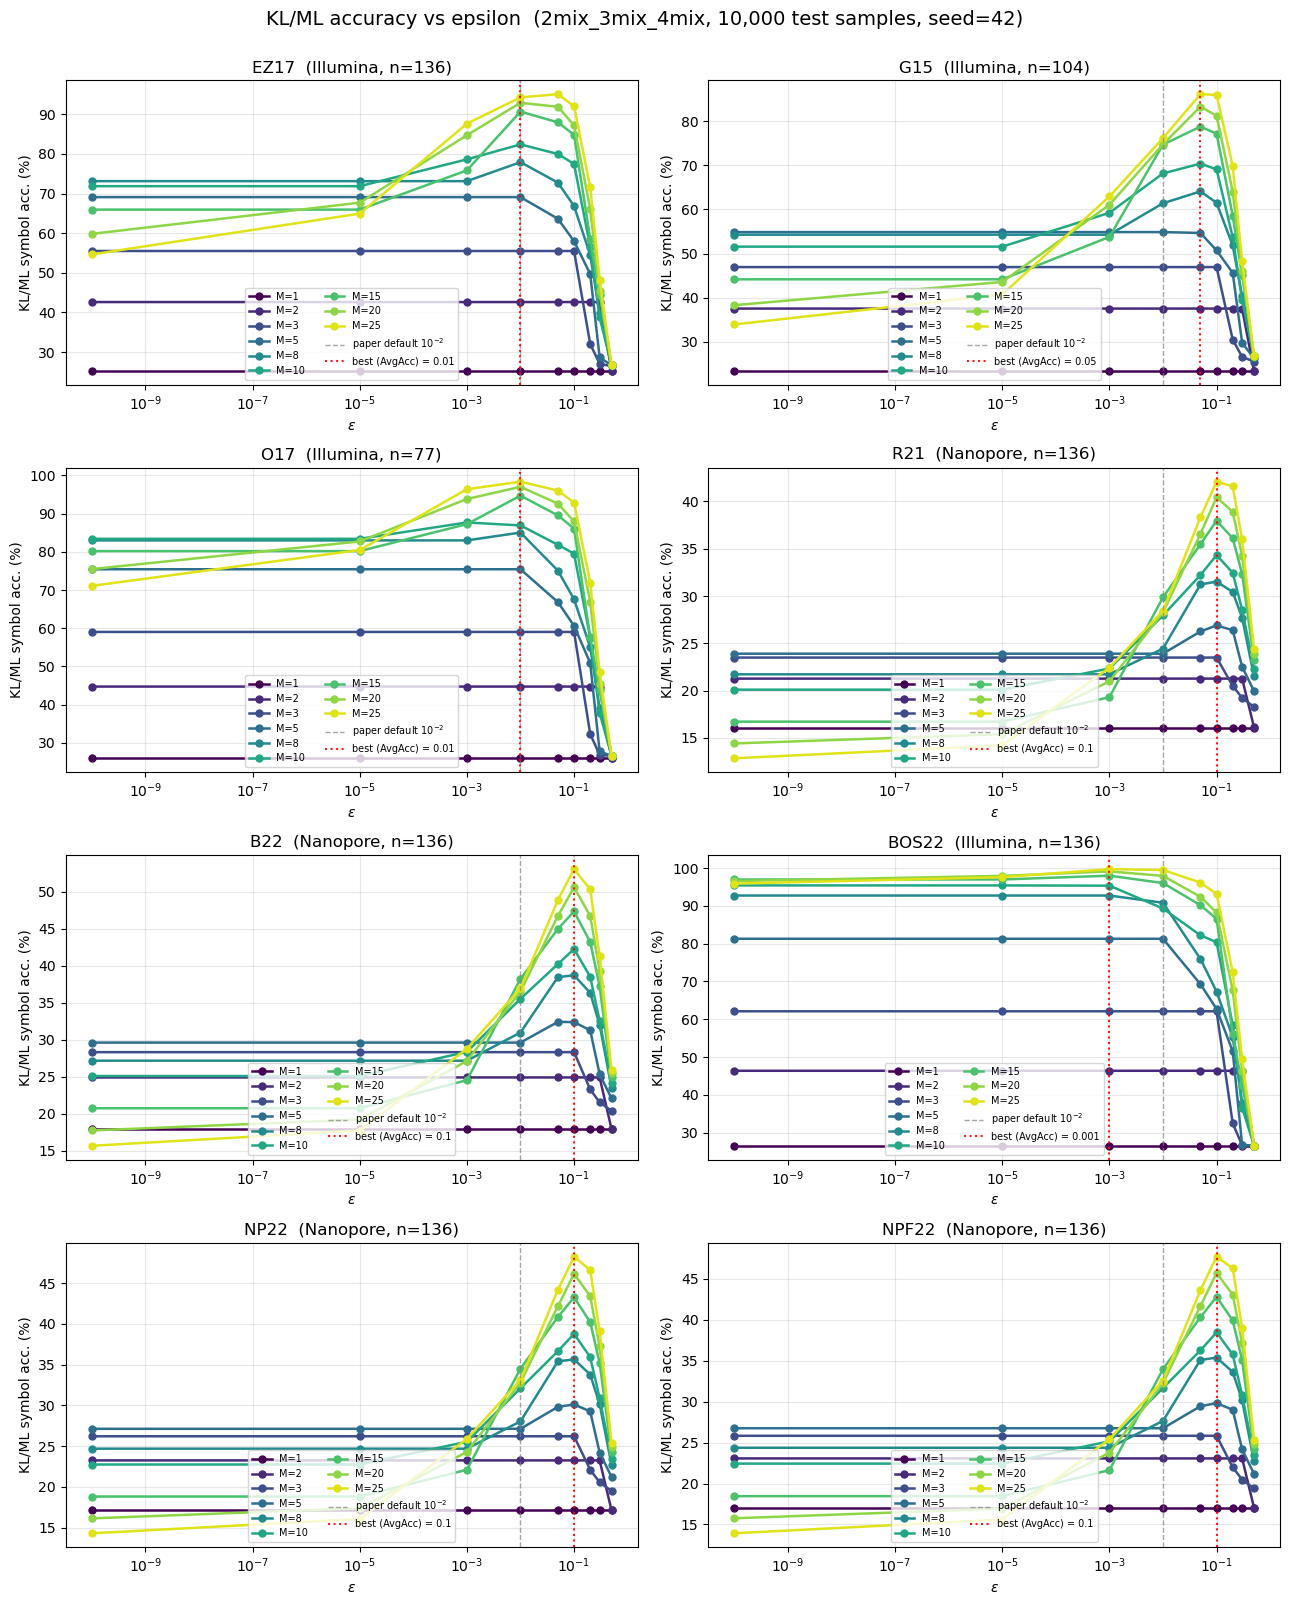

Saved plot -> ./results_epsilon_sweep_2mix_3mix_4mix/epsilon_sweep_2mix_3mix_4mix.png


In [12]:
n_profiles = len(profiles_to_run)
n_cols = 2
n_rows = (n_profiles + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

cmap = plt.cm.viridis(np.linspace(0.0, 0.95, len(COVERAGE_LEVELS)))

for ax, p in zip(axes_flat, profiles_to_run):
    for c_idx, M in enumerate(COVERAGE_LEVELS):
        ys = [profile_kl_acc[p][(M, e)] for e in EPSILON_GRID]
        ax.plot(EPSILON_GRID, ys, 'o-', color=cmap[c_idx], lw=1.8, ms=5, label=f'M={M}')

    ax.set_xscale('log')
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylabel('KL/ML symbol acc. (%)')
    fam = PROFILE_SPECS[p]['family']
    ax.set_title(f'{p}  ({fam}, n={PROFILE_SPECS[p]["seq_length"]})')
    ax.grid(True, alpha=0.3)

    # Reference lines
    ax.axvline(1e-2, color='gray', ls='--', lw=1, alpha=0.7,
               label=r'paper default $10^{-2}$')
    ax.axvline(best_eps_per_profile[p], color='red', ls=':', lw=1.5, alpha=0.9,
               label=f'best (AvgAcc) = {best_eps_per_profile[p]:g}')

    ax.legend(fontsize=7, ncol=2, loc='lower center')

# Hide any unused panels
for j in range(len(profiles_to_run), len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle(f'KL/ML accuracy vs epsilon  ({ALPHABET_MODE}, '
             f'{NUM_TEST:,} test samples, seed={MASTER_SEED})',
             fontsize=14, y=1.0)
plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, f'epsilon_sweep_{ALPHABET_MODE}.png')
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved plot -> {plot_path}')

## 13. Head-to-head: paper default $\epsilon$ vs new optimal $\epsilon$ vs Min.D

For each profile, the three lines are:

- **Min.D** — $\epsilon$-independent baseline.
- **KL/ML, $\epsilon = 10^{-2}$** — the paper default. This is exactly the column
  reproduced in Table:Supp_ResultsA11.
- **KL/ML, best $\epsilon$** — the value chosen by the AvgAcc criterion above.

This is the plot that visually demonstrates whether re-tuning $\epsilon$ recovers the
gap between KL/ML and Min.D under nanopore profiles.

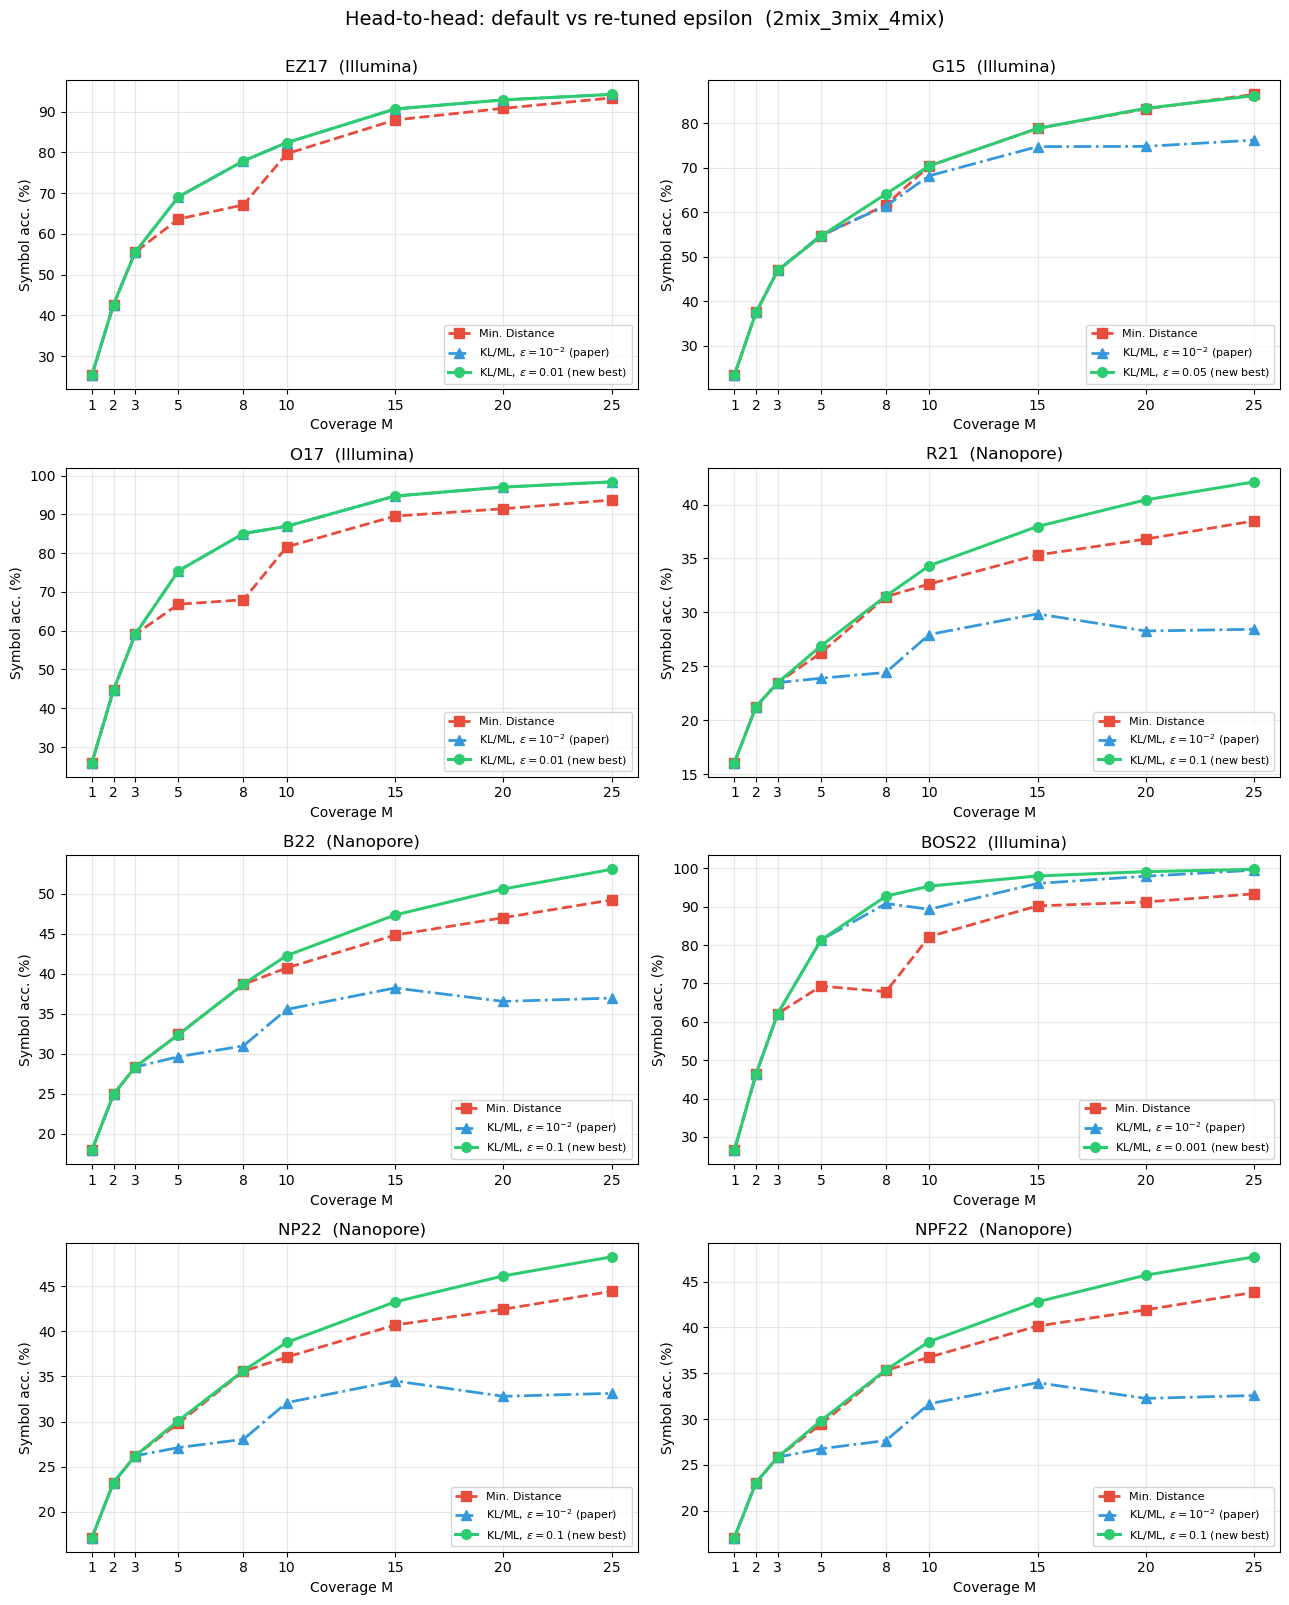

Saved plot -> ./results_epsilon_sweep_2mix_3mix_4mix/head_to_head_2mix_3mix_4mix.png


In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for ax, p in zip(axes_flat, profiles_to_run):
    md_curve   = [profile_md_acc[p][M]                                for M in COVERAGE_LEVELS]
    kl_default = [profile_kl_acc[p][(M, 1e-2)]                         for M in COVERAGE_LEVELS]
    eps_star   = best_eps_per_profile[p]
    kl_best    = [profile_kl_acc[p][(M, eps_star)]                     for M in COVERAGE_LEVELS]

    ax.plot(COVERAGE_LEVELS, md_curve,   's--', c='#e74c3c', lw=2, ms=7, label='Min. Distance')
    ax.plot(COVERAGE_LEVELS, kl_default, '^-.', c='#3498db', lw=2, ms=7,
            label=r'KL/ML, $\epsilon=10^{-2}$ (paper)')
    ax.plot(COVERAGE_LEVELS, kl_best,    'o-',  c='#2ecc71', lw=2.2, ms=7,
            label=fr'KL/ML, $\epsilon={eps_star:g}$ (new best)')

    ax.set_xlabel('Coverage M')
    ax.set_ylabel('Symbol acc. (%)')
    fam = PROFILE_SPECS[p]['family']
    ax.set_title(f'{p}  ({fam})')
    ax.set_xticks(COVERAGE_LEVELS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

for j in range(len(profiles_to_run), len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle(f'Head-to-head: default vs re-tuned epsilon  ({ALPHABET_MODE})',
             fontsize=14, y=1.0)
plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, f'head_to_head_{ALPHABET_MODE}.png')
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved plot -> {plot_path}')

## 14. Takeaways

Read the **summary table in Section 11** alongside the **head-to-head plot in
Section 13** to decide whether to update the paper's $\epsilon$ recommendation:

1. **If `Best eps (AvgAcc) == 1e-2` for every profile**, the paper's choice
   generalises — no change needed.
2. **If `Best eps` is *larger* than $10^{-2}$ for nanopore profiles** (R21, B22, NP22, NPF22),
   the supplementary's observed "KL/ML stagnation" can be explained by under-smoothing.
   Reporting nanopore numbers at the per-profile optimum would tighten the gap to Min.D.
3. **If `Best eps` is *smaller* than $10^{-2}$ for the lowest-error profile BOS22**,
   we are in the high-confidence regime where less smoothing helps. (Expected, mirrors
   Table:Epsilon's behaviour at small M.)
4. **`Delta vs Min.D`** is the headline number: a *positive* value means KL/ML now beats
   Min.D on average for that profile, so the "Min.D > KL/ML under nanopore" anomaly is
   no longer present once $\epsilon$ is tuned per profile.

### Reproducibility

All raw results are in `{RESULTS_DIR}/sweep_<PROFILE>.pkl`. To re-run a single
profile in isolation, set `profiles_to_run = ['R21']` (for example) in Section 9
and re-execute from there. Because the cache builder is seeded only by
`MASTER_SEED`, the test split is identical to the multi-profile run.

### Extending to the eta-based alphabet

Swap the alphabet helpers (Sections 3 & 6) for the eta-based versions in
`train_evaluate_eta_based-Erlich.py` (`build_eta_based_symbol_to_idx`,
`build_eta_based_ideal_vectors`) and point `DATASET_DIR` at the eta-based pickles.
Nothing else changes.